In [1]:
# Data Loading
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor


In [2]:
df = pd.read_csv('data/Medical-Insurance.csv')
df.columns = ['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges']


In [3]:
# Data Understanding
print(df.head(10))
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.columns)

  age  gender     bmi  children smoker  region      charges
0  18       2  33.770         1      0       4   1725.55230
1  28       2  33.000         3      0       4   4449.46200
2  33       2  22.705         0      0       1  21984.47061
3  32       2  28.880         0      0       1   3866.85520
4  31       1  25.740         0      ?       4   3756.62160
5  46       1  33.440         1      0       4   8240.58960
6  37       1  27.740         3      0       1   7281.50560
7  37       2  29.830         2      0       2   6406.41070
8  60       1  25.840         0      0       1  28923.13692
9  25       2  26.220         0      0       2   2721.32080
<class 'pandas.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2771 non-null   str    
 1   gender    2771 non-null   int64  
 2   bmi       2771 non-null   float64
 3   children  2771 non-null   int64  
 4   smoker

In [4]:
df.replace('?', np.nan, inplace=True)

,age,gender,bmi,children,smoker,region,charges
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,NaN,4,3756.62160
...,...,...,...,...,...,...,...
2766,47,1,45.320,1,0,4,8569.86180
2767,21,1,34.600,0,0,3,2020.17700
2768,19,2,26.030,1,1,1,16450.89470
2769,23,2,18.715,0,0,1,21595.38229


In [5]:
df = df.dropna()

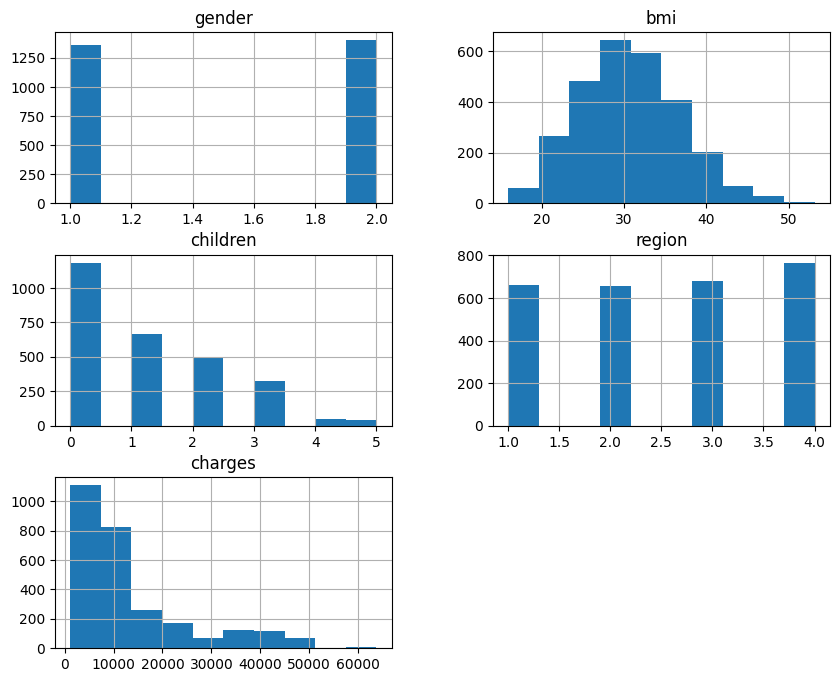

In [6]:
# Exploratory Data Analysis (EDA)
df.hist(figsize=(10,8))
plt.show()

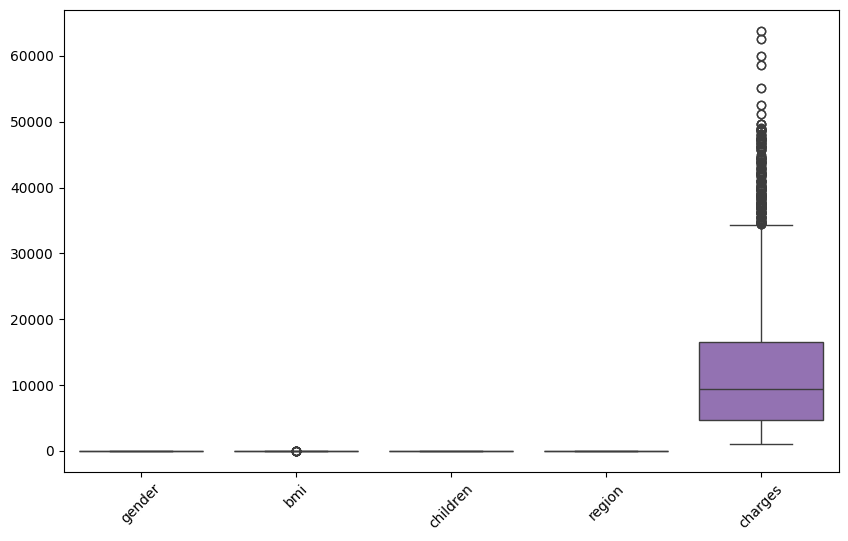

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

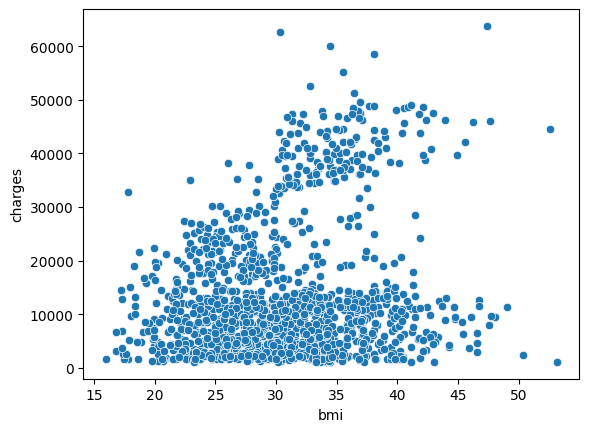

In [8]:
sns.scatterplot(x=df['bmi'], y=df['charges'])
plt.show()

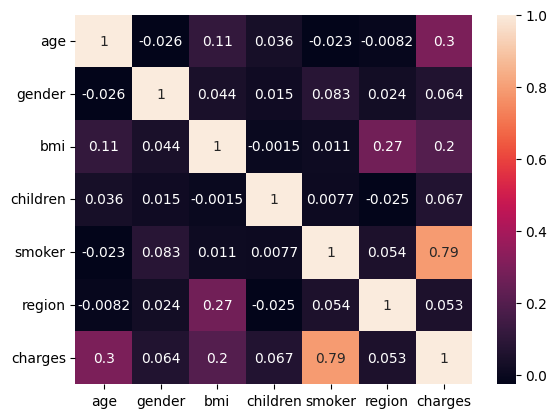

In [9]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [10]:
df_numeric = df.select_dtypes(include=[np.number])

In [11]:
# Data Preprocessing
y = df['charges']
X = df.drop('charges', axis=1)

In [12]:
# hanya encode kolom kategori
categorical_cols = ['gender', 'region', 'smoker']

X = pd.get_dummies(X, drop_first=True)

In [13]:
le = LabelEncoder()

X['gender'] = le.fit_transform(X['gender'])
X['region'] = le.fit_transform(X['region'])

In [14]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# Data Splitting
splits = [
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1)
]

In [16]:
#Fungsi Evaluasi Model
def evaluate_regression(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    print("TRAIN:")
    print("MAE :", mean_absolute_error(y_train, y_pred_train))
    print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
    print("R2  :", r2_score(y_train, y_pred_train))
    
    print("\nTEST:")
    print("MAE :", mean_absolute_error(y_test, y_pred_test))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
    print("R2  :", r2_score(y_test, y_pred_test))

In [17]:
# Pelatihan dan Evaluasi Model (Split 70:30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n=== Split 70:30 ===")

# XGBoost
xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.005,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
print("\n--- XGBoost ---")
evaluate_regression(xgb, X_train, X_test, y_train, y_test)

# Extra Trees
et = ExtraTreesRegressor(
    n_estimators=2000,
    max_depth=17,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
print("\n--- Extra Trees ---")
evaluate_regression(et, X_train, X_test, y_train, y_test)

# HGB
hgb = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.03,
    max_depth=10,
    random_state=42
)
print("\n--- Hist Gradient Boosting ---")
evaluate_regression(hgb, X_train, X_test, y_train, y_test)


=== Split 70:30 ===

--- XGBoost ---
TRAIN:
MAE : 1275.5227045288602
RMSE: 2324.2940387593367
R2  : 0.9634563832061345

TEST:
MAE : 2087.9919825714733
RMSE: 3733.9380911541166
R2  : 0.9056805988966535

--- Extra Trees ---
TRAIN:
MAE : 2022.7800693453898
RMSE: 3364.400644901198
R2  : 0.9234324401781364

TEST:
MAE : 2688.4350924045057
RMSE: 4365.956763750064
R2  : 0.8710487164130536

--- Hist Gradient Boosting ---
TRAIN:
MAE : 1651.3730125100337
RMSE: 2700.503710617098
R2  : 0.9506691103059391

TEST:
MAE : 2457.4461704686005
RMSE: 4094.3700433263593
R2  : 0.8865927053497542


In [18]:
# Pelatihan dan Evaluasi Model (Split 80:20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n=== Split 80:20 ===")

# XGBoost
xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.005,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
print("\n--- XGBoost ---")
evaluate_regression(xgb, X_train, X_test, y_train, y_test)

# Extra Trees
et = ExtraTreesRegressor(
    n_estimators=2000,
    max_depth=17,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
print("\n--- Extra Trees ---")
evaluate_regression(et, X_train, X_test, y_train, y_test)

# HGB
hgb = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.03,
    max_depth=10,
    random_state=42
)
print("\n--- Hist Gradient Boosting ---")
evaluate_regression(hgb, X_train, X_test, y_train, y_test)


=== Split 80:20 ===

--- XGBoost ---
TRAIN:
MAE : 1269.3990810203275
RMSE: 2324.1456724968502
R2  : 0.9630436977944752

TEST:
MAE : 2008.3520331448851
RMSE: 3819.600689896209
R2  : 0.9054958293690812

--- Extra Trees ---
TRAIN:
MAE : 1998.8159989882918
RMSE: 3339.1419690705316
R2  : 0.9237163284153335

TEST:
MAE : 2673.8686711664914
RMSE: 4505.893894840968
R2  : 0.868484490955015

--- Hist Gradient Boosting ---
TRAIN:
MAE : 1641.018369950512
RMSE: 2668.5667897914063
R2  : 0.9512788003499506

TEST:
MAE : 2550.0326532504346
RMSE: 4303.812193783226
R2  : 0.8800164597217093


In [19]:
# Pelatihan dan Evaluasi Model (Split 90:10)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n=== Split 90:10 ===")

# XGBoost
xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.005,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
print("\n--- XGBoost ---")
evaluate_regression(xgb, X_train, X_test, y_train, y_test)

# Extra Trees
et = ExtraTreesRegressor(
    n_estimators=2000,
    max_depth=17,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
print("\n--- Extra Trees ---")
evaluate_regression(et, X_train, X_test, y_train, y_test)

# HGB
hgb = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.03,
    max_depth=10,
    random_state=42
)
print("\n--- Hist Gradient Boosting ---")
evaluate_regression(hgb, X_train, X_test, y_train, y_test)


=== Split 90:10 ===

--- XGBoost ---
TRAIN:
MAE : 1311.9099295045605
RMSE: 2368.6752764316093
R2  : 0.9614278998627863

TEST:
MAE : 1892.6954938841714
RMSE: 3347.7137041759333
R2  : 0.9335777351129572

--- Extra Trees ---
TRAIN:
MAE : 2028.2779824577217
RMSE: 3404.484202909461
R2  : 0.9203171464763159

TEST:
MAE : 2666.1023436200153
RMSE: 4205.389701636227
R2  : 0.8951835241649986

--- Hist Gradient Boosting ---
TRAIN:
MAE : 1698.7665367060147
RMSE: 2727.7819789414134
R2  : 0.9488457710048036

TEST:
MAE : 2510.666001007777
RMSE: 4000.3892189738126
R2  : 0.9051534460501878


In [19]:
sample_input = pd.DataFrame([{
    'age': 25,
    'bmi': 27.5,
    'children': 1,
}])

sample_input = sample_input.reindex(columns=X.columns, fill_value=0)

# scaling
sample_scaled = scaler.transform(sample_input)

# prediksi
prediction = xgb.predict(sample_scaled)

print("=== HASIL PREDIKSI ===")
print("Prediksi:", prediction[0])

=== HASIL PREDIKSI ===
Prediksi: 7722.282
